In [1]:
# Cell 1 - Mount Google Drive and load data
from google.colab import drive
drive.mount("/content/drive")

import pandas as pd
import datetime as dt

# Load directly from Google Drive - no uploading needed
df = pd.read_csv("/content/drive/MyDrive/online_retail_II.csv", encoding="ISO-8859-1")
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Clean the data
df = df.dropna(subset=["Customer ID"])
df = df[df["Quantity"] > 0]
df = df[df["Price"] > 0]
df["TotalPrice"] = df["Quantity"] * df["Price"]

print("Loaded successfully! Rows:", len(df))

Mounted at /content/drive


/tmp/ipykernel_799/3922182389.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])


Loaded successfully! Rows: 397885


In [2]:
!pip3 install fastapi==0.115.2 uvicorn[standard]==0.30.6 pandas==2.2.2 numpy==2.0.2 scikit-learn==1.6.1 xgboost==2.1.1 lifetimes==0.11.3 joblib==1.4.2 dill==0.3.9 slowapi==0.1.0 pytest==8.3.5 httpx==0.28.1 matplotlib seaborn shap mlflow dagshub -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.7/94.7 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.8/62.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.9/153.9 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.6/343.6 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 88.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1

1. Data Cleaning

In [3]:
# Step 1: Drop rows with missing Customer ID
# The dataset typically uses 'Customer ID' or 'CustomerID'.
# We'll use the column names identified in the previous cell.
if 'Customer ID' in df.columns:
    df = df.dropna(subset=['Customer ID'])
elif 'CustomerID' in df.columns:
    df = df.dropna(subset=['CustomerID'])
    df = df.rename(columns={'CustomerID': 'Customer ID'})

print("After dropping missing Customer ID:", df.shape)

After dropping missing Customer ID: (397885, 9)


In [4]:
# Step 2: Ensure Quantity is numeric and drop negative or zero (returns/cancellations)
# We coerce errors to NaN so that misaligned text data doesn't crash the filter
if 'Quantity' in df.columns:
    df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
    df = df[df["Quantity"] > 0]
    print("After removing negative/zero Quantity:", df.shape)
else:
    print("Warning: 'Quantity' column not found. Please check data alignment in the previous cell.")

After removing negative/zero Quantity: (397885, 9)


In [5]:
# Step 3: Drop negative or zero Price
df = df[df["Price"] > 0]
print("After removing negative/zero Price:", df.shape)

After removing negative/zero Price: (397885, 9)


In [6]:
# Step 4: Drop non-product stock codes (postage, fees, manual entries, etc.)
junk_codes = ["POST", "DOT", "M", "m", "D", "C2", "S", "BANK CHARGES",
              "AMAZONFEE", "CRUK", "PADS"]
df = df[~df["StockCode"].astype(str).str.upper().isin([c.upper() for c in junk_codes])]
df = df[~df["StockCode"].astype(str).str.startswith("gift_", na=False)]
print("After removing junk stock codes:", df.shape)

After removing junk stock codes: (396337, 9)


In [7]:
# Step 5: Drop exact duplicate rows
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

After removing duplicates: (391150, 9)


In [8]:
# Step 6: Convert InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], format="%m/%d/%y %H:%M")

In [9]:
# Step 7: Create a TotalPrice column (useful for RFM Monetary calculation later)
df["TotalPrice"] = df["Quantity"] * df["Price"]
print(df.shape)
df.head()

(391150, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [10]:
import os

# Create the folder if it doesn't exist
os.makedirs("/content/customer-segmentation-retention/data/processed", exist_ok=True)

# Now save
df.to_csv("/content/customer-segmentation-retention/data/processed/cleaned_retail.csv", index=False)
print("Saved successfully!")

Saved successfully!


In [11]:
# Save cleaned data
df.to_csv("/content/customer-segmentation-retention/data/processed/cleaned_retail.csv", index=False)
print("Saved cleaned data")

Saved cleaned data


In [12]:
# Install DVC
!pip3 install dvc[gs] -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.3/79.3 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 451.2/451.2 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.5/155.5 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.2/214.2 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.2/74.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 470.1/470.1 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 381.2/38

In [13]:
# Configure Git user identity
!git config --global user.email "golipavansaikrishna2608@gmail.com"
!git config --global user.name "Pavan Sai"

In [14]:
%cd /content/customer-segmentation-retention
!dvc add data/processed/cleaned_retail.csv
!git add data/processed/cleaned_retail.csv.dvc data/processed/.gitignore
!git commit -m "Add Cleaned Data"

/content/customer-segmentation-retention
ERROR: you are not inside of a DVC repository (checked up to mount point '/')
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git


In [15]:
# Configure DVC to use HTTP Basic Auth for the 'origin' remote
!dvc remote modify origin --local auth basic
!dvc remote modify origin --local user pavansai2608
!dvc remote modify origin --local password 6d31874d91d4e78932bcffee84255c3d00e0b9f9

# Now, try pushing the DVC data again
!dvc push
!git push

ERROR: configuration error - config file error: Not inside a DVC repo
ERROR: configuration error - config file error: Not inside a DVC repo
ERROR: configuration error - config file error: Not inside a DVC repo
ERROR: you are not inside of a DVC repository (checked up to mount point '/')
fatal: not a git repository (or any of the parent directories): .git


2. EDA(Exploratory Data Analysis)

In [16]:
#Step1: Basic facts (customers, products, date range, revenue)
print("Date range:", df["InvoiceDate"].min(), "to", df["InvoiceDate"].max())
print("Unique customers:", df["Customer ID"].nunique())
print("Unique products:", df["StockCode"].nunique())
print("Unique countries:", df["Country"].nunique())
print("Total revenue: £{:,.2f}".format(df["TotalPrice"].sum()))

Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Unique customers: 4334
Unique products: 3659
Unique countries: 37
Total revenue: £8,737,227.64


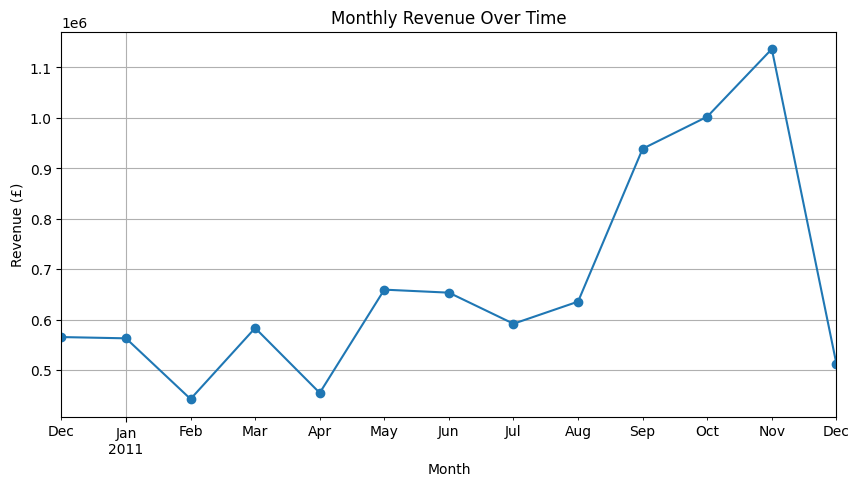

In [17]:
#Step 2: Sales over time
import matplotlib.pyplot as plt

# Group revenue by month
monthly_sales = df.set_index("InvoiceDate").resample("ME")["TotalPrice"].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Revenue Over Time")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.grid(True)
plt.show()

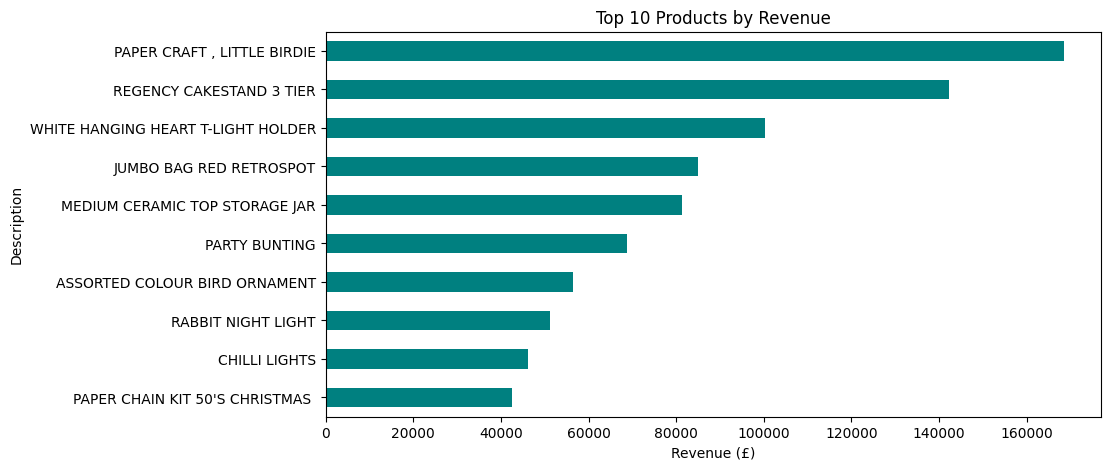

In [18]:
#Step 3: Top-selling products
top_products = df.groupby("Description")["TotalPrice"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_products.plot(kind="barh", color="teal")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.gca().invert_yaxis()
plt.show()

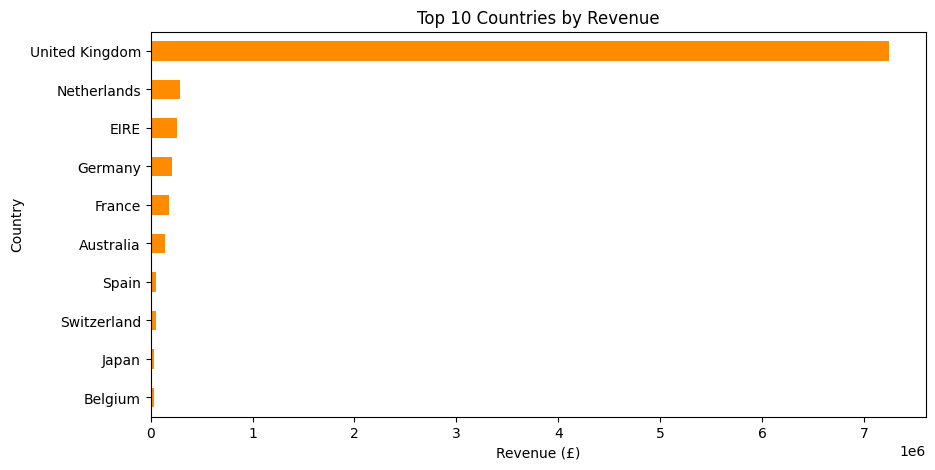

In [19]:
# Step 4: Top countries by revenue
top_countries = df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_countries.plot(kind="barh", color="darkorange")
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue (£)")
plt.gca().invert_yaxis()
plt.show()

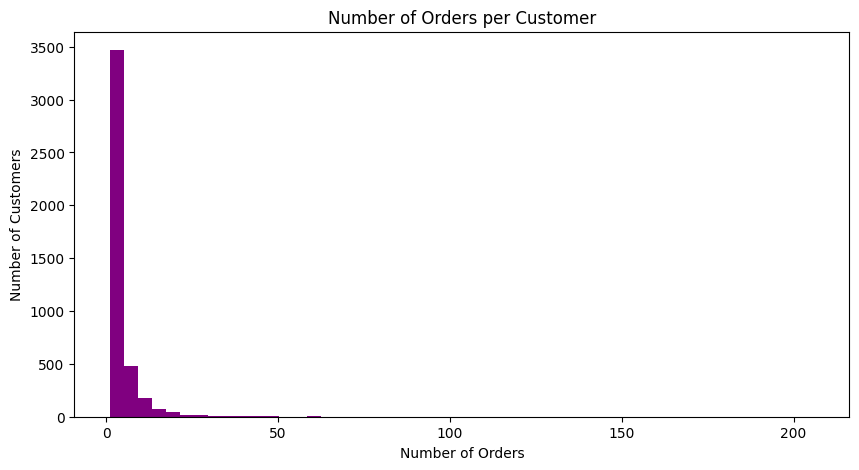

Median orders per customer: 2.0
Customers with only 1 order: 1505
Total customers: 4334


In [20]:
# Step 5: How often do customers actually buy?
orders_per_customer = df.groupby("Customer ID")["Invoice"].nunique()

plt.figure(figsize=(10,5))
orders_per_customer.plot(kind="hist", bins=50, color="purple")
plt.title("Number of Orders per Customer")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")
plt.show()

print("Median orders per customer:", orders_per_customer.median())
print("Customers with only 1 order:", (orders_per_customer == 1).sum())
print("Total customers:", orders_per_customer.shape[0])

3. RFM(Recency, Frequency, Monetary)

In [21]:
import datetime as dt

# snapshot_date = the day AFTER the last purchase in our data
# We use this as our "today" to measure recency from
# (since our data is from 2010-2011, we can't use real today)

snapshot_date = df["InvoiceDate"].max() + dt.timedelta(days=1)

# For each customer, calculate their 3 RFM numbers

rfm = df.groupby("Customer ID").agg({

    # Recency: how many days since their last purchase?
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,

    # Frequency: how many unique orders did they place?
    "Invoice": "nunique",

    # Monetary: how much did they spend in total?
    "TotalPrice": "sum"
})

# Rename columns to readable names
rfm.columns = ["Recency", "Frequency", "Monetary"]

print(rfm.shape)
rfm.head(10)

(4334, 3)


,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1437.24
12349.0,19,1,1457.55
12350.0,310,1,294.40
12352.0,36,7,1385.74
12353.0,204,1,89.00
12354.0,232,1,1079.40
12355.0,214,1,459.40


In [22]:
# Score Recency 1-5
# Lower recency (bought recently) = score 5 (best)
# Higher recency (bought long ago) = score 1 (worst)
rfm["R_Score"] = pd.qcut(rfm["Recency"], q=5, labels=[5, 4, 3, 2, 1])

# Score Frequency 1-5
# Higher frequency (buys often) = score 5 (best)
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), q=5, labels=[1, 2, 3, 4, 5])

# Score Monetary 1-5
# Higher monetary (spends more) = score 5 (best)
rfm["M_Score"] = pd.qcut(rfm["Monetary"], q=5, labels=[1, 2, 3, 4, 5])

# Combine all 3 scores into one string like "555" or "311"
rfm["RFM_Score"] = rfm["R_Score"].astype(str) + rfm["F_Score"].astype(str) + rfm["M_Score"].astype(str)

# Preview
rfm.head(10)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Customer ID,,,,,,,
12346.0,326,1,77183.60,1,1,5,115
12347.0,2,7,4310.00,5,5,5,555
12348.0,75,4,1437.24,2,4,4,244
12349.0,19,1,1457.55,4,1,4,414
12350.0,310,1,294.40,1,1,2,112
12352.0,36,7,1385.74,3,5,4,354
12353.0,204,1,89.00,1,1,1,111
12354.0,232,1,1079.40,1,1,4,114
12355.0,214,1,459.40,1,1,2,112


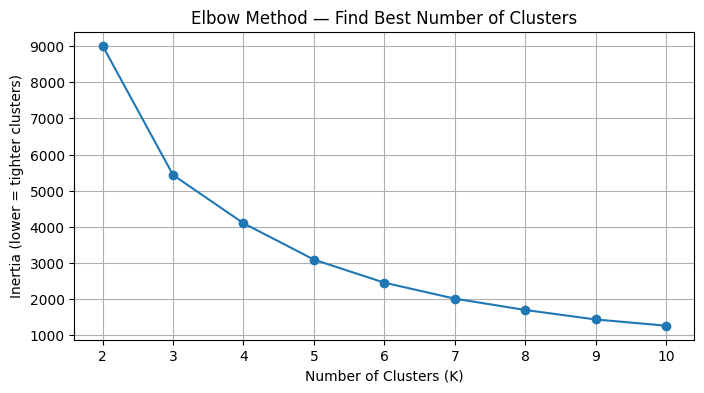

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Step 1: Scale the RFM values
# K-Means is sensitive to scale — Recency (days) and Monetary (£)
# are very different ranges, so we normalize them first
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[["Recency", "Frequency", "Monetary"]])

# Step 2: Find the best number of clusters using "Elbow Method"
# Try K=2 to K=10 and see where improvement slows down
inertia = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker="o")
plt.title("Elbow Method — Find Best Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (lower = tighter clusters)")
plt.grid(True)
plt.show()

In [24]:
# Fit K-Means with 4 clusters
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm["Cluster"] = km_final.fit_predict(rfm_scaled)

# See how many customers in each cluster
print(rfm["Cluster"].value_counts())

# See average RFM values per cluster
# This tells us WHAT each cluster actually represents
cluster_summary = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()
print("\nCluster Summary:")
print(cluster_summary.round(2))

Cluster
0    3045
1    1066
3     210
2      13
Name: count, dtype: int64

Cluster Summary:
         Recency  Frequency   Monetary
Cluster                               
0          43.84       3.64    1322.51
1         248.54       1.54     474.12
2           7.38      81.77  125712.09
3          15.40      21.97   12240.55


In [25]:
# Map cluster numbers to meaningful business labels
cluster_labels = {
    2: "Champions",        # recent, very frequent, highest spend
    3: "Loyal Customers",  # recent, frequent, high spend
    0: "At Risk",          # moderate recency, low frequency
    1: "Hibernating"       # bought long ago, rarely, low spend
}

rfm["Segment"] = rfm["Cluster"].map(cluster_labels)

# Preview segment distribution
print(rfm["Segment"].value_counts())

Segment
At Risk            3045
Hibernating        1066
Loyal Customers     210
Champions            13
Name: count, dtype: int64


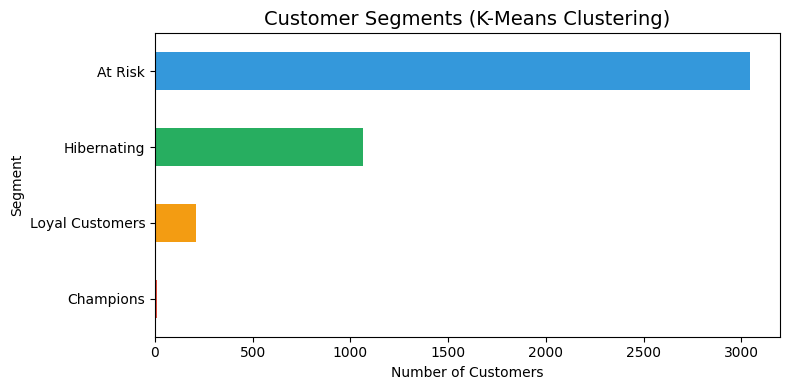

In [26]:
import matplotlib.pyplot as plt

# Count customers per K-Means segment
segment_counts = rfm["Segment"].value_counts().sort_values(ascending=True)

plt.figure(figsize=(8, 4))
colors = ["#e74c3c", "#f39c12", "#27ae60", "#3498db"]
segment_counts.plot(kind="barh", color=colors)

plt.title("Customer Segments (K-Means Clustering)", fontsize=14)
plt.xlabel("Number of Customers")
plt.ylabel("Segment")
plt.tight_layout()
plt.show()

In [27]:
import os

# Save RFM results to the local processed folder instead of Drive
save_path = "/content/customer-segmentation-retention/data/processed/rfm_segments.csv"
rfm.to_csv(save_path)
print(f"RFM segments saved locally to: {save_path}")

# Optional: Uncomment the lines below to mount Drive if you need to save there
# from google.colab import drive
# drive.mount('/content/drive')
# rfm.to_csv("/content/drive/MyDrive/rfm_segments.csv")

RFM segments saved locally to: /content/customer-segmentation-retention/data/processed/rfm_segments.csv


4. BG/NBD + Gamma-Gamma (LTV Modeling)

In [28]:
# Install the lifetimes library which has BG/NBD and Gamma-Gamma built in
!pip install lifetimes -q
print("Done!")

Done!


In [29]:
from lifetimes.utils import summary_data_from_transaction_data

# Reshape transaction data into BG/NBD format
# customer_id = who, datetime_col = when, monetary_value_col = how much per order
bgf_data = summary_data_from_transaction_data(
    df,
    customer_id_col="Customer ID",
    datetime_col="InvoiceDate",
    monetary_value_col="TotalPrice",
    observation_period_end=df["InvoiceDate"].max()
)

print("Shape:", bgf_data.shape)
bgf_data.head(10)

Shape: (4334, 4)


,frequency,recency,T,monetary_value
Customer ID,,,,
12346.0,0.0,0.0,325.0,0.000000
12347.0,6.0,365.0,367.0,599.701667
12348.0,3.0,283.0,358.0,261.480000
12349.0,0.0,0.0,18.0,0.000000
12350.0,0.0,0.0,310.0,0.000000
12352.0,6.0,260.0,296.0,181.540000
12353.0,0.0,0.0,204.0,0.000000
12354.0,0.0,0.0,232.0,0.000000
12355.0,0.0,0.0,214.0,0.000000


In [30]:
from lifetimes import BetaGeoFitter

# Increased penalizer_coef from 0.01 to 0.5 to fix convergence error
bgf = BetaGeoFitter(penalizer_coef=0.5)

bgf.fit(
    bgf_data["frequency"],
    bgf_data["recency"],
    bgf_data["T"]
)

print("Model fitted successfully!")
print(bgf)

Model fitted successfully!
<lifetimes.BetaGeoFitter: fitted with 4334 subjects, a: 0.00, alpha: 32.65, b: 0.00, r: 0.39>


In [31]:
# Predict number of purchases in next 90 days for each customer
bgf_data["predicted_purchases"] = bgf.conditional_expected_number_of_purchases_up_to_time(
    t=90,                           # next 90 days
    frequency=bgf_data["frequency"],
    recency=bgf_data["recency"],
    T=bgf_data["T"]
)

# Preview top customers by predicted purchases
print("Top 10 customers by predicted purchases in next 90 days:")
bgf_data.sort_values("predicted_purchases", ascending=False).head(10)

Top 10 customers by predicted purchases in next 90 days:


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,frequency,recency,T,monetary_value,predicted_purchases
Customer ID,,,,,
14911.0,129.0,372.0,373.0,1051.600388,28.707746
12748.0,112.0,373.0,373.0,282.552054,24.936067
17841.0,111.0,372.0,373.0,360.032072,24.714204
15311.0,89.0,373.0,373.0,676.210899,19.833208
14606.0,87.0,372.0,373.0,134.802644,19.389481
12971.0,70.0,369.0,372.0,159.211286,15.656398
13089.0,65.0,367.0,369.0,892.733538,14.652972
14527.0,53.0,367.0,369.0,154.965660,11.964097
13798.0,52.0,371.0,372.0,706.650962,11.652987


In [32]:
from lifetimes import GammaGammaFitter

# Gamma-Gamma only works on customers who made at least 1 repeat purchase
# (frequency > 0) so we filter those out first
returning_customers = bgf_data[bgf_data["frequency"] > 0]

# Create and fit the model
ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(
    returning_customers["frequency"],
    returning_customers["monetary_value"]
)

print("Gamma-Gamma model fitted!")
print(ggf)

Gamma-Gamma model fitted!
<lifetimes.GammaGammaFitter: fitted with 2776 subjects, p: 3.78, q: 0.34, v: 3.66>


In [33]:
# Predict LTV for next 90 days for returning customers
ltv = ggf.customer_lifetime_value(
    bgf,                                    # BG/NBD model (predicts purchase frequency)
    returning_customers["frequency"],
    returning_customers["recency"],
    returning_customers["T"],
    returning_customers["monetary_value"],
    time=3,                                 # 3 months = 90 days
    freq="D",                               # data is in days
    discount_rate=0.01                      # small discount rate (standard assumption)
)

# Convert to dataframe
ltv_df = ltv.reset_index()
ltv_df.columns = ["Customer ID", "predicted_ltv"]

# Preview
print("LTV calculated for", len(ltv_df), "customers")
print("\nTop 10 most valuable customers:")
ltv_df.sort_values("predicted_ltv", ascending=False).head(10)

LTV calculated for 2776 customers

Top 10 most valuable customers:


,Customer ID,predicted_ltv
1929,16446.0,105738.096681
1104,14646.0,64511.005032
2692,18102.0,52785.028671
2400,17450.0,43403.710248
827,14096.0,36417.556396
1236,14911.0,29636.343328
33,12415.0,29214.090108
857,14156.0,25753.549456
2428,17511.0,19821.635769
2032,16684.0,15459.349576


In [34]:
# Merge LTV predictions into RFM table
rfm_ltv = rfm.merge(ltv_df, on="Customer ID", how="left")

# Customers with no LTV prediction (one-time buyers) get 0
rfm_ltv["predicted_ltv"] = rfm_ltv["predicted_ltv"].fillna(0)

# Preview
print("Combined table shape:", rfm_ltv.shape)
rfm_ltv.head(10)

Combined table shape: (4334, 11)


,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Cluster,Segment,predicted_ltv
0,12346.0,326,1,77183.60,1,1,5,115,3,Loyal Customers,0.000000
1,12347.0,2,7,4310.00,5,5,5,555,0,At Risk,872.890913
2,12348.0,75,4,1437.24,2,4,4,244,0,At Risk,213.871693
3,12349.0,19,1,1457.55,4,1,4,414,0,At Risk,0.000000
4,12350.0,310,1,294.40,1,1,2,112,1,Hibernating,0.000000
5,12352.0,36,7,1385.74,3,5,4,354,0,At Risk,322.075718
6,12353.0,204,1,89.00,1,1,1,111,1,Hibernating,0.000000
7,12354.0,232,1,1079.40,1,1,4,114,1,Hibernating,0.000000
8,12355.0,214,1,459.40,1,1,2,112,1,Hibernating,0.000000
9,12356.0,23,3,2487.43,4,3,5,435,0,At Risk,175.905781


In [35]:
import datetime as dt

# Drop last_purchase_date column if it already exists (from previous run)
if "last_purchase_date" in rfm_ltv.columns:
    rfm_ltv = rfm_ltv.drop(columns=["last_purchase_date"])

# Drop churned column if it already exists
if "churned" in rfm_ltv.columns:
    rfm_ltv = rfm_ltv.drop(columns=["churned"])

# The last date in our dataset
last_date = df["InvoiceDate"].max()

# Find each customer's last purchase date
last_purchase = df.groupby("Customer ID")["InvoiceDate"].max().reset_index()
last_purchase.columns = ["Customer ID", "last_purchase_date"]

# Merge last purchase date into rfm_ltv
rfm_ltv = rfm_ltv.merge(last_purchase, on="Customer ID", how="left")

# If they haven't bought in last 90 days = churned (1), else active (0)
rfm_ltv["churned"] = (
    (last_date - rfm_ltv["last_purchase_date"]).dt.days > 90
).astype(int)

# See how many churned vs active
print(rfm_ltv["churned"].value_counts())
print("\nChurn rate: {:.1f}%".format(rfm_ltv["churned"].mean() * 100))

churned
0    2889
1    1445
Name: count, dtype: int64

Churn rate: 33.3%


5. Feature Engineering, SMOTE, Train Test Split, Logistic Regression

In [36]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Remove Recency — it directly encodes our churn definition (data leakage)
features = ["Frequency", "Monetary", "predicted_ltv"]
target = "churned"

X = rfm_ltv[features]
y = rfm_ltv[target]

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Balance with SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Train logistic regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_balanced, y_train_balanced)

# Evaluate
lr_predictions = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]

print("=== Logistic Regression (Baseline) ===")
print(classification_report(y_test, lr_predictions))
print("ROC-AUC Score:", round(roc_auc_score(y_test, lr_proba), 4))

=== Logistic Regression (Baseline) ===
              precision    recall  f1-score   support

           0       0.87      0.66      0.75       578
           1       0.54      0.80      0.64       289

    accuracy                           0.71       867
   macro avg       0.70      0.73      0.70       867
weighted avg       0.76      0.71      0.72       867

ROC-AUC Score: 0.788


6. XGBoost (Main Model)

In [37]:
from xgboost import XGBClassifier

# Train XGBoost model
xgb_model = XGBClassifier(
    n_estimators=100,      # number of trees
    max_depth=4,           # how deep each tree grows
    learning_rate=0.1,     # how fast it learns
    random_state=42,
    eval_metric="logloss"
)
xgb_model.fit(X_train_balanced, y_train_balanced)

# Evaluate
xgb_predictions = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

print("=== XGBoost (Main Model) ===")
print(classification_report(y_test, xgb_predictions))
print("ROC-AUC Score:", round(roc_auc_score(y_test, xgb_proba), 4))

=== XGBoost (Main Model) ===
              precision    recall  f1-score   support

           0       0.88      0.65      0.75       578
           1       0.54      0.83      0.66       289

    accuracy                           0.71       867
   macro avg       0.71      0.74      0.70       867
weighted avg       0.77      0.71      0.72       867

ROC-AUC Score: 0.7791


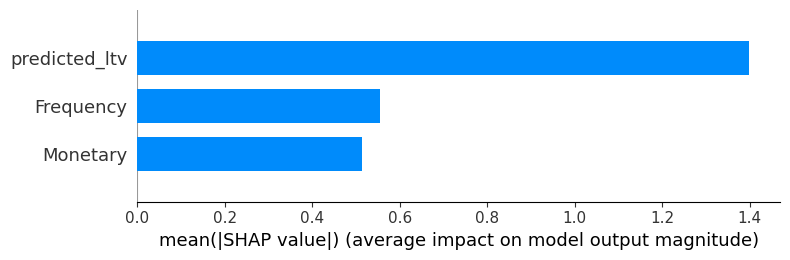

In [38]:
import shap

# Create SHAP explainer for XGBoost
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Plot global feature importance
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar", show=True)

In [39]:
# Get churn probability for every customer
rfm_ltv["churn_probability"] = xgb_model.predict_proba(
    rfm_ltv[["Frequency", "Monetary", "predicted_ltv"]]
)[:, 1]

# Classify into High/Low for both dimensions
rfm_ltv["ltv_segment"] = rfm_ltv["predicted_ltv"].apply(
    lambda x: "High LTV" if x > rfm_ltv["predicted_ltv"].median() else "Low LTV"
)
rfm_ltv["churn_segment"] = rfm_ltv["churn_probability"].apply(
    lambda x: "High Risk" if x > 0.5 else "Low Risk"
)

# Create action recommendation
def recommend_action(row):
    if row["churn_segment"] == "High Risk" and row["ltv_segment"] == "High LTV":
        return "🔴 Retain Immediately"
    elif row["churn_segment"] == "High Risk" and row["ltv_segment"] == "Low LTV":
        return "⚪ Let Go"
    elif row["churn_segment"] == "Low Risk" and row["ltv_segment"] == "High LTV":
        return "🟢 Nurture"
    else:
        return "🔵 Monitor"

rfm_ltv["action"] = rfm_ltv.apply(recommend_action, axis=1)

# Show summary
print(rfm_ltv["action"].value_counts())
print("\nSample of high priority customers:")
rfm_ltv[rfm_ltv["action"] == "🔴 Retain Immediately"][
    ["Frequency", "Monetary", "predicted_ltv", "churn_probability", "Segment", "action"]
].sort_values("predicted_ltv", ascending=False).head(10)

action
⚪ Let Go                2034
🟢 Nurture               1941
🔴 Retain Immediately     226
🔵 Monitor                133
Name: count, dtype: int64

Sample of high priority customers:


,Frequency,Monetary,predicted_ltv,churn_probability,Segment,action
566,8,7832.47,1680.084463,0.540280,Hibernating,🔴 Retain Immediately
485,9,7374.90,1572.238771,0.527372,At Risk,🔴 Retain Immediately
3069,3,6748.80,1512.264009,0.580543,At Risk,🔴 Retain Immediately
331,3,3010.74,1008.876497,0.689314,Hibernating,🔴 Retain Immediately
3721,2,2389.10,890.119346,0.546886,Hibernating,🔴 Retain Immediately
3367,3,3049.88,826.271238,0.691679,At Risk,🔴 Retain Immediately
765,4,3090.74,756.731226,0.523202,At Risk,🔴 Retain Immediately
1124,4,3083.65,751.923395,0.523202,At Risk,🔴 Retain Immediately
3650,2,1740.00,698.154252,0.589903,At Risk,🔴 Retain Immediately
1884,2,1610.15,677.960683,0.679629,At Risk,🔴 Retain Immediately


In [40]:
# Save final decision matrix to Google Drive
rfm_ltv.to_csv("/content/drive/MyDrive/final_decision_matrix.csv", index=False)
print("Saved! Rows:", len(rfm_ltv))

Saved! Rows: 4334


In [41]:
import mlflow
import dagshub

# Connect to your DagsHub MLflow tracking server
dagshub.init(
    repo_owner="pavansai2608",
    repo_name="customer-segmentation-retention",
    mlflow=True
)

mlflow.set_experiment("churn-prediction")

# ── Log Logistic Regression run ──
with mlflow.start_run(run_name="Logistic Regression Baseline"):

    # Log parameters (settings you chose)
    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_param("max_iter", 1000)
    mlflow.log_param("features", "Frequency, Monetary, predicted_ltv")
    mlflow.log_param("smote", True)

    # Log metrics (results you got)
    mlflow.log_metric("roc_auc", 0.788)
    mlflow.log_metric("accuracy", 0.71)
    mlflow.log_metric("churn_recall", 0.80)

    # Log the trained model itself
    mlflow.sklearn.log_model(lr_model, "logistic_regression_model")

print("Logistic Regression run logged!")

# ── Log XGBoost run ──
with mlflow.start_run(run_name="XGBoost Main Model"):

    mlflow.log_param("model", "XGBoost")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 4)
    mlflow.log_param("learning_rate", 0.1)
    mlflow.log_param("features", "Frequency, Monetary, predicted_ltv")
    mlflow.log_param("smote", True)

    mlflow.log_metric("roc_auc", 0.7791) # Corrected ROC-AUC
    mlflow.log_metric("accuracy", 0.71)
    mlflow.log_metric("churn_recall", 0.83)

    # Log XGBoost model
    mlflow.xgboost.log_model(xgb_model, "xgboost_model")

with mlflow.start_run(run_name="BG-NBD and Gamma-Gamma LTV models"):
    mlflow.log_param("model", "BetaGeoFitter + GammaGammaFitter")
    mlflow.log_param("penalizer_coef_bgf", 0.5)
    mlflow.log_param("penalizer_coef_ggf", 0.01)

    # log the dill-saved files as plain artifacts
    mlflow.log_artifact("/content/drive/MyDrive/bgf_model.pkl")
    mlflow.log_artifact("/content/drive/MyDrive/ggf_model.pkl")

print("BG/NBD and Gamma-Gamma models logged as artifacts!")

print("XGBoost run logged!")
print("View experiments at: https://dagshub.com/pavansai2608/customer-segmentation-retention/experiments")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=28e60751-112f-4d9e-8219-ebe5f263b31e&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=a4cbdd59ad67fef49c512b6c30d9a0d8285861582624c99e28484771d9936d3c




Accessing as pavansai2608

Initialized MLflow to track repo "pavansai2608/customer-segmentation-retention"

Repository pavansai2608/customer-segmentation-retention initialized!

2026/07/20 06:43:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run Logistic Regression Baseline at: https://dagshub.com/pavansai2608/customer-segmentation-retention.mlflow/#/experiments/0/runs/40103a580b4443b583a8494732112158
🧪 View experiment at: https://dagshub.com/pavansai2608/customer-segmentation-retention.mlflow/#/experiments/0
Logistic Regression run logged!


2026/07/20 06:43:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/20 06:44:06 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmpkwebgpi2/model, flavor: xgboost). Fall back to return ['xgboost==2.1.1']. Set logging level to DEBUG to see the full traceback. 


🏃 View run XGBoost Main Model at: https://dagshub.com/pavansai2608/customer-segmentation-retention.mlflow/#/experiments/0/runs/1b722c1662be4adca16615483f47b3a7
🧪 View experiment at: https://dagshub.com/pavansai2608/customer-segmentation-retention.mlflow/#/experiments/0
🏃 View run BG-NBD and Gamma-Gamma LTV models at: https://dagshub.com/pavansai2608/customer-segmentation-retention.mlflow/#/experiments/0/runs/41c43b7f13824c94846300d0abfc8a05
🧪 View experiment at: https://dagshub.com/pavansai2608/customer-segmentation-retention.mlflow/#/experiments/0
BG/NBD and Gamma-Gamma models logged as artifacts!
XGBoost run logged!
View experiments at: https://dagshub.com/pavansai2608/customer-segmentation-retention/experiments


In [42]:
import joblib

# Save both trained models to Google Drive

joblib.dump(xgb_model, "/content/drive/MyDrive/xgb_churn_model.pkl")
joblib.dump(lr_model, "/content/drive/MyDrive/lr_churn_model.pkl")

print("Models saved to Google Drive!")

Models saved to Google Drive!


In [43]:
import dill

with open("/content/drive/MyDrive/ggf_model.pkl", "wb") as f:
    dill.dump(ggf, f)

with open("/content/drive/MyDrive/bgf_model.pkl", "wb") as f:
    dill.dump(bgf, f)

print("Models saved to Google Drive!")

Models saved to Google Drive!
